In [2]:
import numpy as np
from quantecon.optimize import brentq
from quantecon.markov import rouwenhorst, tauchen
from interpolation import interp
from numba import njit, guvectorize
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import scipy

# Aiyagari に従ったCalibration

In [3]:
# パラメータ
beta = 0.96
gamma = 3.0
rho = 0.6
sigma = 0.4
alpha = 0.36
delta = 0.08
b = 3.0

## 政策関数の計算のための関数

In [4]:
# Maliarグリッド

@njit
def maliar_grid(a_min, a_max, N, theta):
		a_grid = np.empty(N)
		for i in range(1,N+1):
				a_grid[i-1] = a_min + (a_max - a_min)*((i-1)/(N-1))**theta

		return a_grid

In [6]:
# exponentialグリッド

@njit
def exponential_grid(a_min, a_max, N):
    """
    対数空間を使ったグリッド生成関数
    Parameters:
        a_min: float, グリッドの最小値
        a_max: float, グリッドの最大値
        N: int, グリッドの分割数
    Returns:
        grid: np.ndarray, 生成されたグリッド
    """
    # 対数変換
    log_a_min = np.log1p(a_min)  # log(1 + a_min)
    log_a_max = np.log1p(a_max)  # log(1 + a_max)

    # 等間隔のグリッドを生成
    log_grid = np.linspace(log_a_min, log_a_max, N)

    # 再変換して結果を格納
    grid = np.expm1(log_grid)  # exp(x) - 1
    return grid

In [7]:
# 補間のための関数（外挿あり）
@guvectorize(['void(float64[:], float64[:], float64[:], float64[:])'], '(n),(nq),(n)->(nq)')
def interpolate_y(x, xq, y, yq):
    """Efficient linear interpolation exploiting monotonicity.
    Extrapolates linearly when xq out of domain of x.
    """
    nxq, nx = xq.shape[0], x.shape[0]

    xi = 0
    x_low = x[0]
    x_high = x[1]
    for xqi_cur in range(nxq):
        xq_cur = xq[xqi_cur]
        while xi < nx - 2:
            if x_high >= xq_cur:
                break
            xi += 1
            x_low = x_high
            x_high = x[xi + 1]

        xqpi_cur = (x_high - xq_cur) / (x_high - x_low)
        yq[xqi_cur] = xqpi_cur * y[xi] + (1 - xqpi_cur) * y[xi + 1]

In [8]:
# 解く問題の設定を行う（パラメータ, グリッド, 効用関数や生産関数）
# モデルを変更する場合にはここを修正
class Setting:

    def __init__(self,
                 R=1.01,                          # 粗実質利子率
                 beta=0.99,                          # 割引因子
                 gamma=1,                          # 相対的リスク回避度(異時点間の代替弾力性の逆数)
                 b=0,                             # 内生的な状態変数の最小値, 借入制約
                 a_max=16,                        # 内生的な状態変数の最大値
                 na=21,                           # 内生的な状態変数のグリッド数
                 na_sd = 800,
                 mu=0,                            # 外生変数のAR(1)過程の定数項
                 rho=0.6,                        # 外生変数のAR(1)過程の慣性
                 sigma=0.4,                       # 外生変数のAR(1)過程のショック項の標準偏差
                 nz = 11,                         # 外生変数のグリッド数
                 w = 0,                         # 賃金
                 lambdaPF = 1):                 # 政策関数の更新度

        # パラメータを設定する
        self.R = R
        self.beta = beta
        self.b = b
        self.gamma = gamma
        self.na_sd = na_sd


        # 外生変数の遷移確率とグリッドを設定する

        #1 rowenhorst
        # mc = rouwenhorst(nz, rho, sigma, mu)
        # self.Pz = mc.P
        # self.z_grid = np.exp(mc.state_values)

        #2 tauchen
        mc = tauchen(nz, rho, sigma, mu, n_std = 2)
        self.Pz = np.array(mc.P)
        if mc.state_values is None:
           raise ValueError("mc.state_values is None, cannot apply np.exp.")
        self.z_grid = np.exp(mc.state_values)


        # 内生的な状態変数のグリッドを設定する
        # a_grid = np.linspace(-b, a_max, na)
        a_grid = maliar_grid(-b, a_max, na, 2)
        #a_grid = exponential_grid(-b, a_max, na)
        self.a_grid = a_grid


        # 賃金を設定
        self.w = w

        # 政策関数の更新度を設定する
        self.lambdaPF = lambdaPF

        # CRRA型効用関数と限界効用を定義する
        gamma = self.gamma
        if gamma == 1:
            self.utility = np.log
            self.mutility = njit(lambda x: 1 / x)
        else:
            self.utility = njit(lambda x: x**(1-gamma) / (1 - gamma))
            self.mutility = njit(lambda x: x**(-gamma))


		    # 政策関数の初期値を定義する
        z_grid = self.z_grid
        hfun_old = np.empty((len(a_grid), len(z_grid)))
        for i_a, a in enumerate(a_grid):
            for i_z, z in enumerate(z_grid):
                c_max = 0.5* (R * a + z + b)
                hfun_old[i_a, i_z] = c_max
        self.hfun_old = hfun_old


# 特定のアルゴリズムを実行して政策関数を更新する関数を出力する
# FOCを変更する場合やアルゴリズムを変更する場合はここを修正

# 今期の状態変数について繰り返し記号はi, 来期の状態変数について繰り返し記号はj

def EGMIteration(hp): # hpはSettingクラスからつくられるインスタンス

    # インスタンスからローカル変数を定義する
    R, beta, b, gamma, mutility = hp.R, hp.beta, hp.b, hp.gamma, hp.mutility
    a_grid, z_grid, Pz, w = hp.a_grid, hp.z_grid, hp.Pz, hp.w

    @njit
    def UpdatePF(h_old):

        h_new = np.empty_like(h_old)
        a_tilde = np.empty_like(a_grid)
        aprime_new = np.empty_like(a_grid)

        for i_z in range(len(z_grid)): # 今期の生産性について繰り返し
            z = z_grid[i_z]

            for j_a in range(len(a_grid)): # 来期の資産について繰り返し
                aprime = a_grid[j_a]

                expectation = 0
                for j_z in range(len(z_grid)): # 来期の生産性について繰り返し

                    # オイラー方程式の右辺を計算する
                    expectation += mutility(h_old[j_a, j_z]) * Pz[i_z, j_z]

                rhs = R * beta * expectation
                c_tilde = 1/((rhs)**(1/gamma))

                # 今期の資産を計算
                a_tilde[j_a] = (aprime - z*w + c_tilde)/R


            # 来期の資産の政策関数をinterpolationで求める
            interpolate_y(a_tilde, a_grid, a_grid, aprime_new)

            for i_a in range(len(a_grid)): # 今期の資産について繰り返し

                # 来期の資産の政策関数をinterpolationで求める
                #aprime_new = interp(a_tilde, a_grid, a_grid[i_a])

                # 借り入れ制約を考慮しつつ来期の資産を求める
                if aprime_new[i_a] < -b:
                    aprime_new[i_a] = -b
                else:
                    aprime_new[i_a] = aprime_new[i_a]

                # 消費の政策関数を求める
                h_new[i_a,i_z] = R * a_grid[i_a] + z*w - aprime_new[i_a]

        return h_new

    return UpdatePF



# メイン関数：特定のアルゴリズムでiterationを行い、問題を解く関数
# 基本的には変更する必要がない

def SolveProblem(hp,               # Settingクラスからつくられるインスタンス
                Algorithm,         # アルゴリズムを指定
                tol=1e-4,          # 許容繰り返し誤差
                max_iter=10000,     # iteration回数の最大値
                verbose=True,      # 進捗を表示するかどうか
                print_skip=25):    # 進捗を何回ごとに表示するか


    # インスタンスからローカル変数を定義する
    # R, beta, b, mutility = hp.R, hp.beta, hp.b, hp.mutility
    # a_grid, z_grid, Pz = hp.a_grid, hp.z_grid, hp.Pz
    lambdaPF = hp.lambdaPF
    hfun_old = hp.hfun_old

    # チェックのために外生変数のグリッドと遷移確率を表示する
    # print(f"About exogenous variables:")
    # print(f"grid is {z_grid}.")
    # print(f"Transition matrix is {Pz}.")



    # 政策関数を更新する関数を取得する
    UpdatePF = Algorithm(hp)

    # iterationを行い、問題を解く
    i = 0
    error = tol + 1

    while i < max_iter and error > tol:

        # 政策関数を更新する
        hfun_new_tilde = UpdatePF(hfun_old)

        # 古い政策関数と加重平均する
        hfun_new = lambdaPF*hfun_new_tilde + (1-lambdaPF)*hfun_old

        error = np.max(np.abs(hfun_new-hfun_old))
        i += 1
        if verbose and i % print_skip == 0:      # 進捗をprint_skip回ごとに表示する
            print(f"PF Error at iteration {i} is {error}.")
        hfun_old = hfun_new

    if i == max_iter:
        print("Failed to converge!")

    if verbose and i < max_iter:
        print(f"\nConverged in {i} iterations.")

    return hfun_new

## 定常分布の計算のための関数

In [9]:
from numba import njit
import numpy as np


@njit
def gridlookup2(x0, xgrid):
    nx = np.shape(xgrid)[0]
    ix = 0
    for jx in range(nx):
        if x0 <= xgrid[jx]:
            break
        ix += 1
    ix = min(max(1, ix), nx-1)
    return ix - 1

#sd = solve_sd(sd_grid, len(hp.a_grid), len(hp.z_grid),len(a_grid_sd),a_grid, a_grid_sd, hp.Pz, hfun_aprime)


@njit
def solve_sd(mu0: np.ndarray,
                        na: int,
                        nz: int,
                        na_sd: int,    # mu0.shape[0]のこと
                        agrid: np.ndarray,
                        agrid_sd: np.ndarray,
                        Pz: np.ndarray,
                        pfgrid: np.ndarray,
                        critmu: float = 1e-6):

    # -1. 政策関数の行列を補間して、行数を na 個から na_sd 個に変える
    # pfgrid -> pfgrid_new
    pfgrid_new = np.empty((na_sd,nz))              # 空の箱を用意
    for z_index in range(nz):
      aprime_new = np.empty(na_sd)
      interpolate_y(agrid, agrid_sd, pfgrid[:, z_index], aprime_new)
      pfgrid_new[:,z_index] = aprime_new


    # 0. transition matrixを計算
    G = np.zeros((na_sd*nz,na_sd*nz))
    weight = np.zeros((na_sd,nz))

    for iz in range(nz):
      for ia in range(na_sd):

        # 政策関数 pfgrid[ia, iz] に合わせる
        aprime = pfgrid_new[ia, iz]


        if aprime < agrid_sd[0]:
            weight[ia, iz] = 1.0
            jtilde = 0
        elif aprime > agrid_sd[-1]:
            weight[ia, iz] = 0
            jtilde = na_sd - 2
        else:
          # aprimeが落ちる区間の左端のグリッドのインデックスを探す
          jtilde = gridlookup2(aprime, agrid_sd)
          # 重み weight[ia, iz] に格納
          weight[ia, iz] = (agrid_sd[jtilde+1] - aprime) / (agrid_sd[jtilde+1] - agrid_sd[jtilde])

        # スタックしたときの現在の状態のインデックスを計算
        i_s = iz * na_sd + ia

        # 次期外生状態 jz でループ
        for jz in range(nz):

            # スタックしたときの次期の状態のインデックスを計算
            j_s  = jz * na_sd + jtilde

            # 遷移確率行列 G に代入
            #   - Pe[iz, jz] : 現在 iz から次期 jz への外生ショックの遷移確率
            G[i_s, j_s ] += weight[ia, iz]   * Pz[iz, jz]
            G[i_s, j_s + 1] += (1.0 - weight[ia, iz]) * Pz[iz, jz]


    diffmu = 1.0e4
    mu1    = np.zeros((na_sd, nz))

    # 分布の初期値をスタックしてベクトル化
    mu0 = mu0.T.flatten()

    while diffmu > 1e-6:

        # 1. 分布の更新 : dist_new = G' * dist
        mu1 = G.T @ mu0

        # 2. 収束判定
        diffmu = np.max(np.abs(mu1 - mu0))

        # 3. normalizeして次のループへ
        mu0 = mu1 / np.sum(mu1)

    sd = mu0.reshape(nz, na_sd).T
    return sd


## 総労働供給を求める

In [10]:
# 生産性の定常分布を求める

hp = Setting(nz = 7, rho = rho, sigma = sigma) # 生産性の定常分布を求めるために必要ない変数については初期値のまま

muZ_old = np.ones(len(hp.z_grid)) / len(hp.z_grid)

tol=1E-11
maxit=100^4

for it in range(maxit):
  muZ_new = muZ_old @ hp.Pz
  if np.max(np.abs(muZ_new - muZ_old)) < tol: break
  muZ_old = muZ_new

# 総労働供給を求める
Lbar = sum(muZ_new*hp.z_grid)
print(Lbar)

1.125707392526809


## 実行

In [64]:
import time

start_time = time.time()  # 計測開始

r0 = 0.029

diff = 1
loop = 0
while abs(diff) > 1e-10:
    loop += 1
    print("loop: ", loop)

    # 1
    K0d = ((r0 + delta) / alpha) ** (1 / (alpha - 1)) * Lbar
    w0 = (1 - alpha) * (K0d/Lbar) ** alpha

    

    # 2
    hp = Setting(beta=beta, gamma = gamma, b = b, a_max = 45, lambdaPF = 1, na = 300, na_sd= 800, nz = 7, rho = rho, sigma = sigma, R = 1 + r0, w = w0)
    hfun_c = SolveProblem(hp,EGMIteration)

    # 3
    # hfun_c から 次期のアセット aの政策関数を求める
    hfun_aprime = np.empty((len(hp.a_grid), len(hp.z_grid)))
    a_mesh, z_mesh = np.meshgrid(hp.a_grid, hp.z_grid, indexing='ij') # ユニバーサル関数を使用するためのグリッドを生成
    hfun_aprime = hp.R * a_mesh + hp.w * z_mesh - hfun_c


    # 定常分布用のグリッドを用意
    a_grid_sd = np.linspace(-hp.b, hp.a_grid[-1], hp.na_sd)
    #a_grid_sd = maliar_grid(-hp.b , hp.a_grid[-1], hp.na_sd, 2)

    # 初期の定常分布を定義
    sd_grid = np.full((len(a_grid_sd), len(hp.z_grid)),
                      1 / (len(a_grid_sd) * len(hp.z_grid))
                      )

    sd = solve_sd(sd_grid, len(hp.a_grid), len(hp.z_grid),len(a_grid_sd),hp.a_grid, a_grid_sd, hp.Pz, hfun_aprime)


    # 4
    #Amesh, _ = np.meshgrid(a_grid_sd, hp.z_grid, indexing='ij')
    #K0s = np.sum(Amesh * sd)
    # --- hfun_aprime を補間 ---
    hfun_aprime_interp = np.empty((len(a_grid_sd), len(hp.z_grid)))
    for iz in range(len(hp.z_grid)):
        interpolate_y(hp.a_grid, a_grid_sd, hfun_aprime[:, iz], hfun_aprime_interp[:, iz])
    # 総資本ストック供給 K_s の計算
    K0s = np.sum(hfun_aprime_interp * sd)

    
    print("K0s: ", K0s)
    diff = (K0s - K0d)
    print("diff: ", diff)

    r0 = r0 - 0.001 * diff

r0 = r0 + 0.001 * diff


end_time = time.time()  # 計測終了

print("Elapsed time:", end_time - start_time, "seconds")

loop:  1
PF Error at iteration 25 is 0.06564813647442946.
PF Error at iteration 50 is 0.013324175669055194.
PF Error at iteration 75 is 0.0040030683025520375.
PF Error at iteration 100 is 0.001307579033152706.
PF Error at iteration 125 is 0.00041897356408071573.
PF Error at iteration 150 is 0.00012674439736315435.

Converged in 155 iterations.
K0s:  6.767319339358734
diff:  -0.5133158854982236
loop:  2
PF Error at iteration 25 is 0.06567070517267837.
PF Error at iteration 50 is 0.01334307352820474.
PF Error at iteration 75 is 0.004022514760919194.
PF Error at iteration 100 is 0.0013252265098913085.
PF Error at iteration 125 is 0.0004314241042777667.
PF Error at iteration 150 is 0.00013351705874242725.

Converged in 156 iterations.
K0s:  7.115556370219356
diff:  -0.11182711760578012
loop:  3
PF Error at iteration 25 is 0.06567531230321322.
PF Error at iteration 50 is 0.01334683923761304.
PF Error at iteration 75 is 0.004026409814315457.
PF Error at iteration 100 is 0.0013287996121107426

## 均衡の確認

In [63]:
# --- 労働市場均衡の確認 ---
# 労働需要の計算
L_demand = (w0 / ((1 - alpha) * K0d ** alpha)) ** (-1 / alpha)
# 労働市場誤差の計算
labor_market_error = L_demand - Lbar
print("労働市場誤差",labor_market_error)
# 労働供給の計算
# Lbarをつかう


# --- 財市場均衡の確認 ---
# 総産出 Y の計算
# 財の供給側
Y = (K0d ** alpha) * (L_demand ** (1 - alpha))

#　財の需要側
# --- hfun_c を補間 ---
hfun_c_interp = np.empty((len(a_grid_sd), len(hp.z_grid)))
for iz in range(len(hp.z_grid)):
    interpolate_y(hp.a_grid, a_grid_sd, hfun_c[:, iz], hfun_c_interp[:, iz])

# 総消費 C の計算
C = np.sum(hfun_c_interp * sd)

# 総投資 I の計算
#I = delta * K0s
# 財市場の均衡誤差
goods_market_error = C - (Y - delta * K0s)
print("財市場誤差",goods_market_error)

# --- 資本ストック市場均衡の確認 ---

# 資本ストックの供給側
#K0sをつかう

#　資本ストックの需要側
#K0dをつかう


# 資本ストック市場の均衡誤差
capital_market_error = K0d-K0s
print("資本ストック市場誤差",capital_market_error)



労働市場誤差 -2.220446049250313e-16
財市場誤差 -9.722711524773331e-11
資本ストック市場誤差 0.07439757946160341


In [65]:
r0 # 均衡時の金利

np.float64(0.029648923018072714)

In [66]:
K0d # 均衡時の資本

np.float64(7.21342211347104)

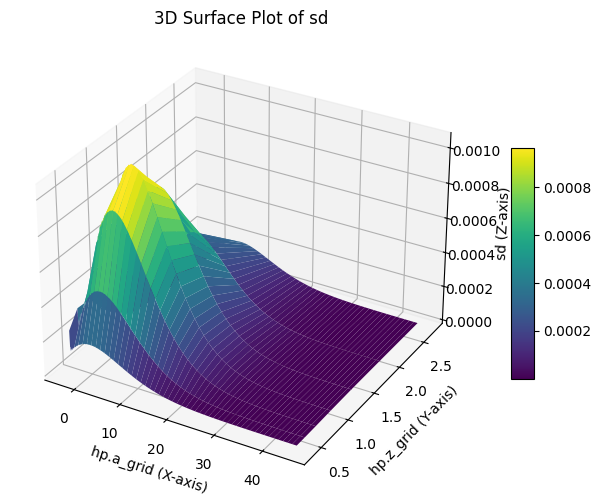

In [ ]:
# 定常分布 sd のプロット
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# メッシュグリッドを作成
X, Y = np.meshgrid(a_grid_sd, hp.z_grid)
Z = sd.T  # データの形状を合わせるため転置（必要なら）

# 3Dプロット
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

# 軸ラベル
ax.set_xlabel('hp.a_grid (X-axis)')
ax.set_ylabel('hp.z_grid (Y-axis)')
ax.set_zlabel('sd (Z-axis)')
ax.set_title('3D Surface Plot of sd')

plt.show()

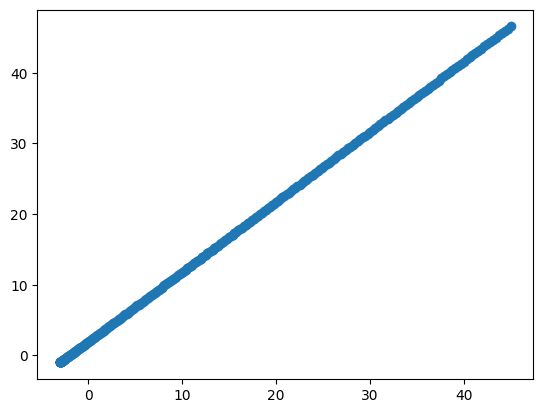

In [ ]:
# hp.a_grid と hfun_a[0]のデータフレームを作る
df = pd.DataFrame({
    'x_axis': hp.a_grid,
    'y_axis': hfun_aprime[:, -1]})
# plot
plt.plot('x_axis', 'y_axis', data=df, linestyle='-', marker='o')

## めも

財市場の均衡を収束条件にした場合

In [59]:
import time

start_time = time.time()  # 計測開始

r0 = 0.029

goods_market_error  = 1
loop = 0
while abs(goods_market_error ) > 1e-10:
    loop += 1
    print("loop: ", loop)

    # 1
    K0d = ((r0 + delta) / alpha) ** (1 / (alpha - 1)) * Lbar
    w0 = (1 - alpha) * (K0d/Lbar) ** alpha

    

    # 2
    hp = Setting(beta=beta, gamma = gamma, b = b, a_max = 45, lambdaPF = 1, na = 300, na_sd= 800, nz = 7, rho = rho, sigma = sigma, R = 1 + r0, w = w0)
    hfun_c = SolveProblem(hp,EGMIteration)

    # 3
    # hfun_c から 次期のアセット aの政策関数を求める
    hfun_aprime = np.empty((len(hp.a_grid), len(hp.z_grid)))
    a_mesh, z_mesh = np.meshgrid(hp.a_grid, hp.z_grid, indexing='ij') # ユニバーサル関数を使用するためのグリッドを生成
    hfun_aprime = hp.R * a_mesh + hp.w * z_mesh - hfun_c


    # 定常分布用のグリッドを用意
    a_grid_sd = np.linspace(-hp.b, hp.a_grid[-1], hp.na_sd)
    #a_grid_sd = maliar_grid(-hp.b , hp.a_grid[-1], hp.na_sd, 2)

    # 初期の定常分布を定義
    sd_grid = np.full((len(a_grid_sd), len(hp.z_grid)),
                      1 / (len(a_grid_sd) * len(hp.z_grid))
                      )

    sd = solve_sd(sd_grid, len(hp.a_grid), len(hp.z_grid),len(a_grid_sd),hp.a_grid, a_grid_sd, hp.Pz, hfun_aprime)


    # 4
    #Amesh, _ = np.meshgrid(a_grid_sd, hp.z_grid, indexing='ij')
    #K0s = np.sum(Amesh * sd)
    # --- hfun_aprime を補間 ---
    hfun_aprime_interp = np.empty((len(a_grid_sd), len(hp.z_grid)))
    for iz in range(len(hp.z_grid)):
        interpolate_y(hp.a_grid, a_grid_sd, hfun_aprime[:, iz], hfun_aprime_interp[:, iz])
    # 総資本ストック供給 K_s の計算
    K0s = np.sum(hfun_aprime_interp * sd)

    

    
    #print("K0s: ", K0s)
    #diff = (K0s - K0d)
    #print("diff: ", diff)
    # 総産出 Y の計算
    # 財の供給側
    Y = (K0d ** alpha) * (L_demand ** (1 - alpha))

    #　財の需要側
    # --- hfun_c を補間 ---
    hfun_c_interp = np.empty((len(a_grid_sd), len(hp.z_grid)))
    for iz in range(len(hp.z_grid)):
        interpolate_y(hp.a_grid, a_grid_sd, hfun_c[:, iz], hfun_c_interp[:, iz])

    # 総消費 C の計算
    C = np.sum(hfun_c_interp * sd)

    # 総投資 I の計算
    #I = delta * K0s
    # 財市場の均衡誤差
    goods_market_error = C - (Y - delta * K0s)
    print("財市場誤差",goods_market_error)

    


    r0 = r0 - 0.001 * goods_market_error 

r0 = r0 + 0.001 * goods_market_error 


end_time = time.time()  # 計測終了

print("Elapsed time:", end_time - start_time, "seconds")

loop:  1
PF Error at iteration 25 is 0.06564813647442946.
PF Error at iteration 50 is 0.013324175669055194.
PF Error at iteration 75 is 0.0040030683025520375.
PF Error at iteration 100 is 0.001307579033152706.
PF Error at iteration 125 is 0.00041897356408071573.
PF Error at iteration 150 is 0.00012674439736315435.

Converged in 155 iterations.
財市場誤差 -0.04837244204652125
loop:  2
PF Error at iteration 25 is 0.06565036298992055.
PF Error at iteration 50 is 0.013326070132706036.
PF Error at iteration 75 is 0.004005012096399696.
PF Error at iteration 100 is 0.0013093301653839262.
PF Error at iteration 125 is 0.0004201930221370276.
PF Error at iteration 150 is 0.0001273966855137587.

Converged in 155 iterations.
財市場誤差 -0.04494123349091628
loop:  3
PF Error at iteration 25 is 0.06565241296946311.
PF Error at iteration 50 is 0.013327809091151721.
PF Error at iteration 75 is 0.004006797096167247.
PF Error at iteration 100 is 0.0013109405510931538.
PF Error at iteration 125 is 0.000421317485233

In [60]:
# --- 労働市場均衡の確認 ---
# 労働需要の計算
L_demand = (w0 / ((1 - alpha) * K0d ** alpha)) ** (-1 / alpha)
# 労働市場誤差の計算
labor_market_error = L_demand - Lbar
print("労働市場誤差",labor_market_error)
# 労働供給の計算
# Lbarをつかう


# --- 財市場均衡の確認 ---
# 総産出 Y の計算
# 財の供給側
Y = (K0d ** alpha) * (L_demand ** (1 - alpha))

#　財の需要側
# --- hfun_c を補間 ---
hfun_c_interp = np.empty((len(a_grid_sd), len(hp.z_grid)))
for iz in range(len(hp.z_grid)):
    interpolate_y(hp.a_grid, a_grid_sd, hfun_c[:, iz], hfun_c_interp[:, iz])

# 総消費 C の計算
C = np.sum(hfun_c_interp * sd)

# 総投資 I の計算
#I = delta * K0s
# 財市場の均衡誤差
goods_market_error = C - (Y - delta * K0s)
print("財市場誤差",goods_market_error)

# --- 資本ストック市場均衡の確認 ---

# 資本ストックの供給側
#K0sをつかう

#　資本ストックの需要側
#K0dをつかう


# 資本ストック市場の均衡誤差
capital_market_error = K0d-K0s
print("資本ストック市場誤差",capital_market_error)


労働市場誤差 -2.220446049250313e-16
財市場誤差 -9.722711524773331e-11
資本ストック市場誤差 0.07439757946160341


In [61]:
r0

np.float64(0.02955573762084808)

In [62]:
K0d

np.float64(7.223011216281483)

資本ストック市場誤差が大きくなってしまう

ひとつの市場の誤差を収束条件にすると、３つの市場のうち、ひとつの市場について、0.008ぐらいの誤差は出てしまうのかも。速度を重視するなら、資本ストック市場の均衡を収束条件にするのが速い。